In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Renaa\Renaad3\archive\Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
df.shape

(6435, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [9]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [13]:
df['Date'].head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]

In [14]:
df['Month'] = df['Date'].dt.to_period('M')

In [15]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()


Analysis:
The table shows the monthly revenue from January 2011 to August 2012. The revenue fluctuates frequently, 
going up and down from month to month. The highest revenue recorded was 2.7 in July 2011, while the lowest was 1.6 in August 2011.
Overall, there is no strong long-term growth,
but when comparing the same months in 2011 and 2012, the figures are slightly higher in 2012, indicating a small improvement.



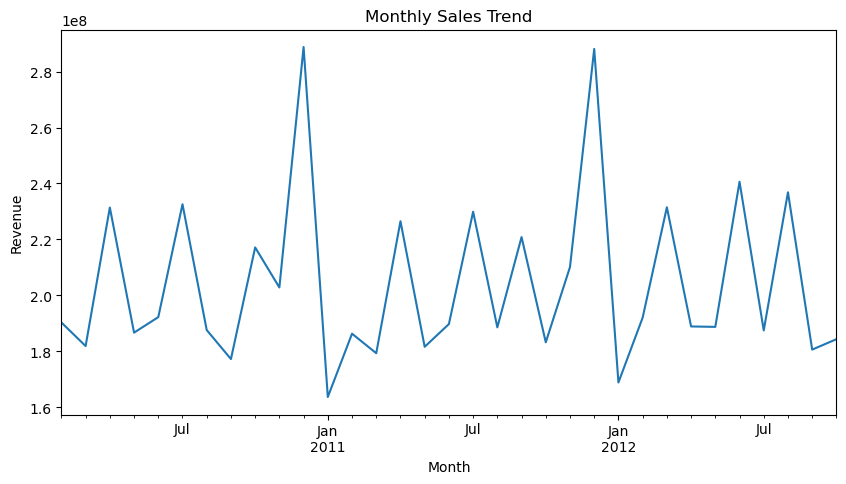

In [25]:
plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
print("""
Analysis:
The table shows the monthly revenue from January 2011 to August 2012. The revenue fluctuates frequently, 
going up and down from month to month. The highest revenue recorded was 2.7 in July 2011, while the lowest was 1.6 in August 2011.
Overall, there is no strong long-term growth,
but when comparing the same months in 2011 and 2012, the figures are slightly higher in 2012, indicating a small improvement.
""")
plt.show()

In [17]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


Analysis:
The bar chart compares average weekly sales during holiday and non-holiday periods.
Sales during holidays appear higher than regular weeks.
This suggests that holiday seasons positively impact revenue.
Businesses can use this insight to plan promotions and inventory.



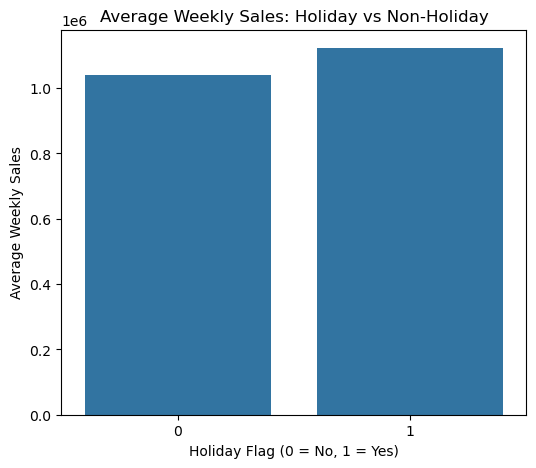

In [23]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=holiday_sales)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag (0 = No, 1 = Yes)")
plt.ylabel("Average Weekly Sales")
print("""
Analysis:
The bar chart compares average weekly sales during holiday and non-holiday periods.
Sales during holidays appear higher than regular weeks.
This suggests that holiday seasons positively impact revenue.
Businesses can use this insight to plan promotions and inventory.
""")
plt.show()



Analysis:
The boxplot shows the distribution of weekly sales.
There are several outliers, indicating unusually high sales in some weeks.
These spikes may be due to special events or promotional campaigns.
Outliers should be carefully analyzed before model building.



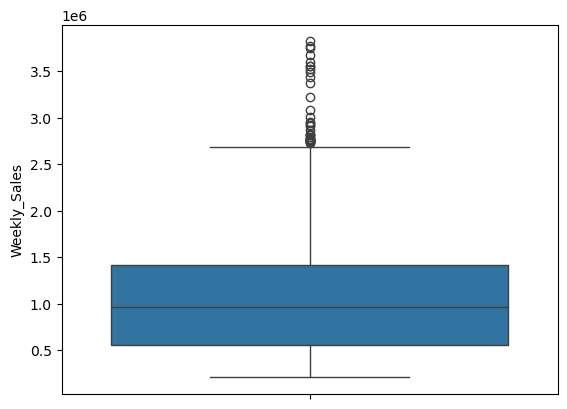

In [24]:
sns.boxplot(y=df['Weekly_Sales'])
print("""
Analysis:
The boxplot shows the distribution of weekly sales.
There are several outliers, indicating unusually high sales in some weeks.
These spikes may be due to special events or promotional campaigns.
Outliers should be carefully analyzed before model building.
""")
plt.show()


Analysis:
The table shows how different factors are correlated with weekly sales. Temperature has the strongest positive relationship (0.22),
meaning sales go up when it is warmer. 
On the other hand, fuel price (-0.21) and unemployment (-0.16) have negative correlations, meaning higher fuel prices or unemployment lead to lower sales. 
The holiday flag has a very weak positive effect (0.06), while CPI shows a slight negative relationship (-0.11). 
Overall, weather seems to influence sales the most, while economic factors like fuel prices also play a noticeable role.



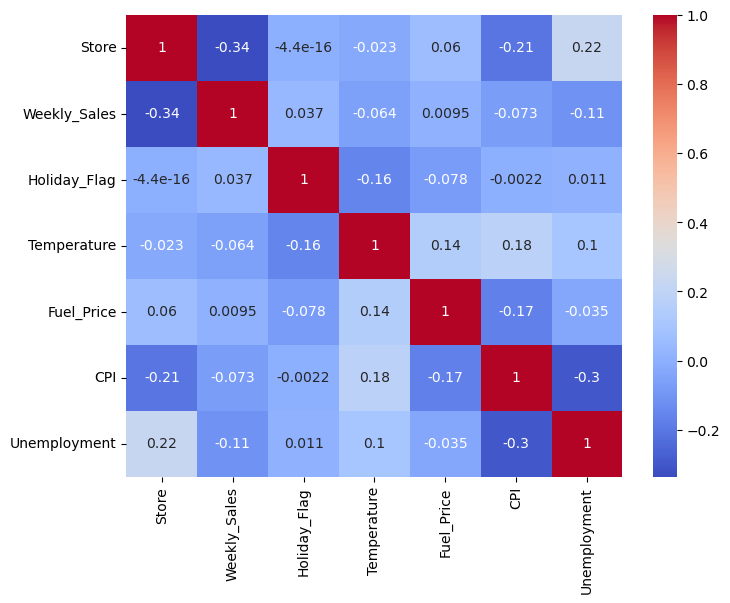

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm')
print("""
Analysis:
The table shows how different factors are correlated with weekly sales. Temperature has the strongest positive relationship (0.22),
meaning sales go up when it is warmer. 
On the other hand, fuel price (-0.21) and unemployment (-0.16) have negative correlations, meaning higher fuel prices or unemployment lead to lower sales. 
The holiday flag has a very weak positive effect (0.06), while CPI shows a slight negative relationship (-0.11). 
Overall, weather seems to influence sales the most, while economic factors like fuel prices also play a noticeable role.
""")
plt.show()